# OSM Quality & Distribution Dashboard

이 노트북은 OSM 기반 raw 데이터가 layer/score에 사용할 수 있는 품질인지 확인한다.

파일 기반 raw와 달리 OSM은 공식 행정 데이터가 아니라 커뮤니티 기반 지도 데이터이므로, 단순 row 수뿐 아니라 수집 시점, query_key, tag 구조, geometry 유효성, 서울 범위 포함 여부, layer 연결 여부를 함께 검증한다.

In [11]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from shapely.geometry import box
from sqlalchemy import text

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURE_DIR = PROJECT_ROOT / "analysis" / "figures" / "raw" / "osm"
TABLE_DIR = PROJECT_ROOT / "analysis" / "tables" / "raw" / "osm"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

KOREAN_FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")
if KOREAN_FONT_PATH.exists():
    fm.fontManager.addfont(str(KOREAN_FONT_PATH))
    KOREAN_FONT = fm.FontProperties(fname=str(KOREAN_FONT_PATH))
    KOREAN_FONT_NAME = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None
    KOREAN_FONT_NAME = "DejaVu Sans"

sns.set_theme(style="whitegrid", font=KOREAN_FONT_NAME, rc={"axes.unicode_minus": False})
plt.rcParams["font.family"] = KOREAN_FONT_NAME
plt.rcParams["axes.unicode_minus"] = False


def apply_korean_font(ax):
    if KOREAN_FONT is None:
        return ax
    ax.title.set_fontproperties(KOREAN_FONT)
    ax.xaxis.label.set_fontproperties(KOREAN_FONT)
    ax.yaxis.label.set_fontproperties(KOREAN_FONT)
    for text in ax.get_xticklabels() + ax.get_yticklabels() + ax.texts:
        text.set_fontproperties(KOREAN_FONT)
    return ax


SEOUL_BBOX = {
    "min_lon": 126.7,
    "max_lon": 127.2,
    "min_lat": 37.4,
    "max_lat": 37.75,
}

from src.database.postgresql import engine

## 1. OSM raw 적재 상태 확인

`osm_raw`에 실제로 어떤 query_key가 적재되어 있는지 확인한다.

확인할 것:
- query_key별 row 수
- geometry 개수
- 수집 시점 범위
- 너무 오래된 수집 데이터인지 여부

주의할 점: `fetched_at`은 우리 DB에 저장한 시점이고, OSM 객체 자체의 수정일은 현재 schema에 저장되어 있지 않다.

In [3]:
osm_status_sql = '''
SELECT
    query_key,
    COUNT(*) AS row_count,
    COUNT(geom) AS geom_count,
    MIN(fetched_at) AS first_fetched_at,
    MAX(fetched_at) AS last_fetched_at
FROM osm_raw
GROUP BY query_key
ORDER BY row_count DESC
'''

try:
    osm_status = pd.read_sql(osm_status_sql, engine)
    display(osm_status)
    osm_status.to_csv(TABLE_DIR / "osm_raw_query_key_status.csv", index=False, encoding="utf-8-sig")
except Exception as e:
    osm_status = pd.DataFrame()
    print("DB 조회 실패:", e)

,query_key,row_count,geom_count,first_fetched_at,last_fetched_at
0,leisure=park,2230,2230,2026-06-24 06:15:26.685458,2026-06-24 06:15:26.685458
1,landuse=grass,1714,1714,2026-06-24 06:17:10.736496,2026-06-24 06:17:10.736496
2,natural=wood,1050,1050,2026-06-24 06:14:41.803774,2026-06-24 06:14:41.803774
3,leisure=garden,976,976,2026-06-24 06:16:59.352338,2026-06-24 06:16:59.352338
4,landuse=forest,394,394,2026-06-24 06:14:58.505555,2026-06-24 06:14:58.505555
5,landuse=farmland,111,111,2026-06-24 06:18:49.249649,2026-06-24 06:18:49.249649
6,natural=scrub,70,70,2026-06-24 06:14:49.811354,2026-06-24 06:14:49.811354
7,landuse=meadow,46,46,2026-06-24 06:18:41.113534,2026-06-24 06:18:41.113534
8,landuse=allotments,10,10,2026-06-24 06:18:57.234190,2026-06-24 06:18:57.234190


## 2. OSM raw geometry 로드

`osm_raw`의 geometry와 properties를 GeoDataFrame으로 불러온다.

이 단계부터는 OSM 데이터를 지도/공간 데이터로 검증한다.

In [4]:
osm_sql = '''
SELECT
    id AS osm_raw_id,
    query_key,
    properties,
    fetched_at,
    geom
FROM osm_raw
'''

try:
    osm_gdf = gpd.read_postgis(osm_sql, engine, geom_col="geom", crs="EPSG:4326")
    print("osm_raw rows:", len(osm_gdf))
    display(osm_gdf.head())
except Exception as e:
    osm_gdf = gpd.GeoDataFrame()
    print("OSM GeoDataFrame 로드 실패:", e)

osm_raw rows: 6601


,osm_raw_id,query_key,properties,fetched_at,geom
0,1,natural=wood,"{'ele': None, 'area': None, 'name': '고덕산', 'ty...",2026-06-24 06:14:41.803774,POINT (127.14702 37.56339)
1,2,natural=wood,"{'ele': None, 'area': None, 'name': '감나무', 'ty...",2026-06-24 06:14:41.803774,POINT (126.90220 37.50269)
2,3,natural=wood,"{'ele': None, 'area': None, 'name': None, 'typ...",2026-06-24 06:14:41.803774,POINT (126.97504 37.56643)
3,4,natural=wood,"{'ele': None, 'area': None, 'name': None, 'typ...",2026-06-24 06:14:41.803774,POINT (126.97402 37.56453)
4,5,natural=wood,"{'ele': None, 'area': None, 'name': None, 'typ...",2026-06-24 06:14:41.803774,POINT (127.01057 37.57152)


## 3. query_key별 row 수 시각화

OSM raw가 어떤 query_key에 집중되어 있는지 확인한다.

특정 query_key에 row가 과도하게 몰려 있으면, OSM 기반 score가 특정 태그에 지나치게 의존할 수 있다.

,query_key,row_count
6,leisure=park,2230
3,landuse=grass,1714
8,natural=wood,1050
5,leisure=garden,976
2,landuse=forest,394
1,landuse=farmland,111
7,natural=scrub,70
4,landuse=meadow,46
0,landuse=allotments,10


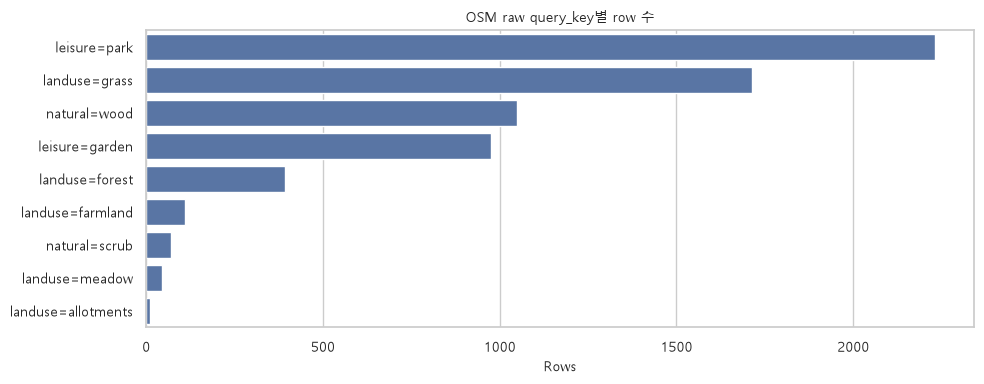

In [5]:
if osm_gdf.empty:
    print("osm_raw가 비어 있어 query_key 분포를 그릴 수 없습니다.")
else:
    osm_query_counts = (
        osm_gdf.groupby("query_key")
        .size()
        .reset_index(name="row_count")
        .sort_values("row_count", ascending=False)
    )
    display(osm_query_counts)
    osm_query_counts.to_csv(TABLE_DIR / "osm_query_key_row_count.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=osm_query_counts, x="row_count", y="query_key")
    ax.set_title("OSM raw query_key별 row 수")
    ax.set_xlabel("Rows")
    ax.set_ylabel("")
    apply_korean_font(ax)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "osm_query_key_row_count.png", dpi=160)
    plt.show()

## 4. properties tag 구조 확인

OSM의 핵심 정보는 properties 안의 tag다.

어떤 tag key가 많이 들어있는지 확인해서 `name` 기반 해석이 가능한지, 아니면 `natural`, `landuse`, `leisure` 같은 분류 tag 중심으로 봐야 하는지 판단한다.

In [6]:
if osm_gdf.empty:
    osm_flat = pd.DataFrame()
    tag_key_counts = pd.DataFrame()
    print("osm_raw가 비어 있습니다.")
else:
    props = pd.json_normalize(osm_gdf["properties"].apply(lambda x: x or {}).tolist())
    osm_flat = pd.concat([osm_gdf.drop(columns=["properties"]).reset_index(drop=True), props], axis=1)
    tag_key_counts = (
        props.notna()
        .sum()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "tag_key", 0: "non_null_rows"})
    )

    print("properties columns:", len(props.columns))
    display(osm_flat.head())
    display(tag_key_counts.head(40))
    tag_key_counts.to_csv(TABLE_DIR / "osm_tag_key_non_null_counts.csv", index=False, encoding="utf-8-sig")

properties columns: 121


,osm_raw_id,query_key,fetched_at,geom,ele,area,name,type,ways,fixme,...,golf,bicycle_parking,office,location,material,government,min_height,opening_date,source:opening_hours,produce
0,1,natural=wood,2026-06-24 06:14:41.803774,POINT (127.14702 37.56339),None,None,고덕산,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,natural=wood,2026-06-24 06:14:41.803774,POINT (126.90220 37.50269),None,None,감나무,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,natural=wood,2026-06-24 06:14:41.803774,POINT (126.97504 37.56643),None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,natural=wood,2026-06-24 06:14:41.803774,POINT (126.97402 37.56453),None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,natural=wood,2026-06-24 06:14:41.803774,POINT (127.01057 37.57152),None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,tag_key,non_null_rows
0,nodes,6517
1,leisure,3230
2,landuse,2290
3,name,1495
4,natural,1147
5,name:ko,331
6,name:en,293
7,name:ja,229
8,ways,215
9,type,215


## 5. 주요 OSM tag 값 분포

`natural`, `landuse`, `leisure`, `name`의 값 분포를 확인한다.

여기서 알 수 있는 것:
- 실제로 어떤 녹지/공원 tag가 들어왔는지
- name 결측이 많아 이름 기반 분석이 어려운지
- OSM row가 어떤 tag 조합에 치우쳐 있는지

In [7]:
tag_value_rows = []

if osm_flat.empty:
    print("osm_flat이 비어 있습니다.")
else:
    for tag_key in ["natural", "landuse", "leisure", "name"]:
        if tag_key not in osm_flat.columns:
            continue
        print(f"\n[{tag_key}]")
        counts = osm_flat[tag_key].value_counts(dropna=False).head(20)
        display(counts)
        for tag_value, row_count in counts.items():
            tag_value_rows.append(
                {
                    "tag_key": tag_key,
                    "tag_value": tag_value,
                    "row_count": int(row_count),
                }
            )

tag_value_summary = pd.DataFrame(tag_value_rows)
display(tag_value_summary)
tag_value_summary.to_csv(TABLE_DIR / "osm_tag_value_summary.csv", index=False, encoding="utf-8-sig")


[natural]


natural
None        4357
NaN         1097
wood        1071
scrub         73
tree_row       2
water          1
Name: count, dtype: int64


[landuse]


landuse
None                 4311
grass                1722
forest                399
farmland              111
meadow                 47
allotments             10
recreation_ground       1
Name: count, dtype: int64


[leisure]


leisure
None               3134
park               2247
garden              977
NaN                 237
pitch                 2
fitness_station       2
nature_reserve        1
golf_course           1
Name: count, dtype: int64


[name]


name
None        5036
NaN           70
놀이터           23
근린공원           8
사각공원           5
푸른수목원          5
햇님어린이공원        5
평화도봉공원         5
쌈지공원           4
우면공원           4
화단             3
경의선숲길공원        3
까치공원           3
샛별어린이공원        3
꿈동산어린이공원       3
문정 근린공원        3
이촌한강공원         3
서리풀공원          3
반포한강공원         3
역삼공원           3
Name: count, dtype: int64

,tag_key,tag_value,row_count
0,natural,None,4357
1,natural,NaN,1097
2,natural,wood,1071
3,natural,scrub,73
4,natural,tree_row,2
5,natural,water,1
6,landuse,None,4311
7,landuse,grass,1722
8,landuse,forest,399
9,landuse,farmland,111


## 6. geometry 품질 확인

OSM raw geometry가 null이거나 invalid이면 공간 분석 근거로 쓰기 어렵다.

geometry type도 함께 확인한다. 녹지 면적 분석은 Polygon/MultiPolygon 중심으로만 가능하다.

In [8]:
if osm_gdf.empty:
    geometry_quality = pd.DataFrame()
    geom_type_counts = pd.DataFrame()
    print("osm_gdf가 비어 있습니다.")
else:
    geometry_quality = pd.DataFrame([
        {
            "total_rows": len(osm_gdf),
            "null_geometry_rows": int(osm_gdf.geometry.isna().sum()),
            "valid_geometry_rows": int(osm_gdf.geometry.is_valid.sum()),
            "invalid_geometry_rows": int((~osm_gdf.geometry.is_valid).sum()),
        }
    ])
    geom_type_counts = (
        osm_gdf.geometry.geom_type
        .value_counts(dropna=False)
        .reset_index()
        .rename(columns={"index": "geometry_type", "count": "row_count"})
    )

    display(geometry_quality)
    display(geom_type_counts)
    geometry_quality.to_csv(TABLE_DIR / "osm_geometry_quality.csv", index=False, encoding="utf-8-sig")
    geom_type_counts.to_csv(TABLE_DIR / "osm_geometry_type_counts.csv", index=False, encoding="utf-8-sig")

,total_rows,null_geometry_rows,valid_geometry_rows,invalid_geometry_rows
0,6601,0,6601,0


,geometry_type,row_count
0,Polygon,6495
1,Point,84
2,MultiPolygon,20
3,LineString,2


## 7. 서울 bbox 포함 여부 확인

현재 단계에서는 정확한 행정경계 spatial join이 아니라 서울 bbox 기준으로 1차 이상치를 확인한다.

모든 geometry가 서울 bbox와 교차하면 수집 범위가 크게 벗어나지는 않았다고 볼 수 있다.

In [12]:
if osm_gdf.empty:
    bbox_quality = pd.DataFrame()
    print("osm_gdf가 비어 있습니다.")
else:
    bbox = (
        SEOUL_BBOX["min_lon"],
        SEOUL_BBOX["min_lat"],
        SEOUL_BBOX["max_lon"],
        SEOUL_BBOX["max_lat"],
    )
    osm_gdf = osm_gdf.copy()
    seoul_bbox_geom = box(*bbox)
    osm_gdf["bbox_intersects"] = osm_gdf.geometry.intersects(seoul_bbox_geom)

    bbox_quality = (
        osm_gdf.groupby("query_key")
        .agg(
            total_rows=("osm_raw_id", "count"),
            bbox_intersect_rows=("bbox_intersects", "sum"),
        )
        .reset_index()
    )
    bbox_quality["bbox_intersect_rate"] = bbox_quality["bbox_intersect_rows"] / bbox_quality["total_rows"]

    display(bbox_quality)
    bbox_quality.to_csv(TABLE_DIR / "osm_seoul_bbox_quality.csv", index=False, encoding="utf-8-sig")

,query_key,total_rows,bbox_intersect_rows,bbox_intersect_rate
0,landuse=allotments,10,10,1.0
1,landuse=farmland,111,111,1.0
2,landuse=forest,394,394,1.0
3,landuse=grass,1714,1714,1.0
4,landuse=meadow,46,46,1.0
5,leisure=garden,976,976,1.0
6,leisure=park,2230,2230,1.0
7,natural=scrub,70,70,1.0
8,natural=wood,1050,1050,1.0


## 8. geometry 면적 분포 확인

polygon 기반 OSM 녹지는 row 수만 보면 안 된다. 작은 polygon이 많이 들어온 경우와 큰 polygon이 적게 들어온 경우의 의미가 다르기 때문이다.

면적 계산은 반드시 meter 단위 투영좌표계인 EPSG:5179로 변환한 뒤 계산한다.

In [13]:
if osm_gdf.empty:
    area_summary = pd.DataFrame()
    print("osm_gdf가 비어 있습니다.")
else:
    osm_polygon = osm_gdf[osm_gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    if osm_polygon.empty:
        area_summary = pd.DataFrame()
        print("polygon geometry가 없습니다.")
    else:
        osm_polygon_5179 = osm_polygon.to_crs(epsg=5179)
        osm_polygon["area_km2"] = osm_polygon_5179.geometry.area / 1_000_000
        area_summary = (
            osm_polygon.groupby("query_key")["area_km2"]
            .agg(["count", "sum", "min", "median", "mean", "max"])
            .reset_index()
            .sort_values("sum", ascending=False)
        )
        display(area_summary)
        area_summary.to_csv(TABLE_DIR / "osm_polygon_area_summary.csv", index=False, encoding="utf-8-sig")

,query_key,count,sum,min,median,mean,max
8,natural=wood,1010,256.859030,3.214898e-06,0.001867,0.254316,45.207934
6,leisure=park,2205,38.843325,3.723323e-06,0.001658,0.017616,1.667397
1,landuse=farmland,111,7.401963,8.936435e-05,0.004632,0.066684,2.507906
2,landuse=forest,394,5.687388,2.564396e-06,0.000912,0.014435,1.253993
3,landuse=grass,1714,4.653796,2.494996e-06,0.000399,0.002715,0.259588
5,leisure=garden,955,1.883993,1.630893e-07,0.000205,0.001973,0.615664
7,natural=scrub,70,0.219601,9.033057e-06,0.000406,0.003137,0.060012
0,landuse=allotments,10,0.029250,2.497987e-05,0.000352,0.002925,0.014084
4,landuse=meadow,46,0.022005,1.428658e-05,0.000259,0.000478,0.002641


## 9. nature_layer 반영 여부 확인

OSM raw가 단순히 적재만 된 것인지, 실제 `nature_layer`에 연결되어 score/layer 후보로 쓰이는지 확인한다.

In [14]:
nature_sql = '''
SELECT
    id AS nature_layer_id,
    osm_raw_id,
    green_type,
    green_weight,
    geom
FROM nature_layer
'''

try:
    nature_gdf = gpd.read_postgis(nature_sql, engine, geom_col="geom", crs="EPSG:4326")
    print("nature_layer rows:", len(nature_gdf))
    display(nature_gdf.head())
except Exception as e:
    nature_gdf = gpd.GeoDataFrame()
    print("nature_layer 조회 실패:", e)

nature_layer rows: 6515


,nature_layer_id,osm_raw_id,green_type,green_weight,geom
0,1,41,wood,3,"POLYGON ((126.79667 37.60246, 126.79661 37.602..."
1,2,42,wood,3,"POLYGON ((126.92510 37.49467, 126.92484 37.493..."
2,3,43,wood,3,"POLYGON ((126.91329 37.49246, 126.91263 37.491..."
3,4,44,wood,3,"POLYGON ((127.05442 37.62164, 127.05463 37.621..."
4,5,45,wood,3,"POLYGON ((126.93492 37.48249, 126.93426 37.481..."


## 10. nature_layer green_type 분포

실제 layer에 반영된 OSM 녹지 유형이 무엇인지 확인한다.

raw에 많이 적재되어도 layer에 반영되지 않으면 score 근거로 보기 어렵다.

,green_type,green_weight,row_count
6,park,2,2205
4,grass,2,1714
8,wood,3,1010
3,garden,2,955
2,forest,3,394
1,farmland,1,111
7,scrub,3,70
5,meadow,2,46
0,allotments,1,10


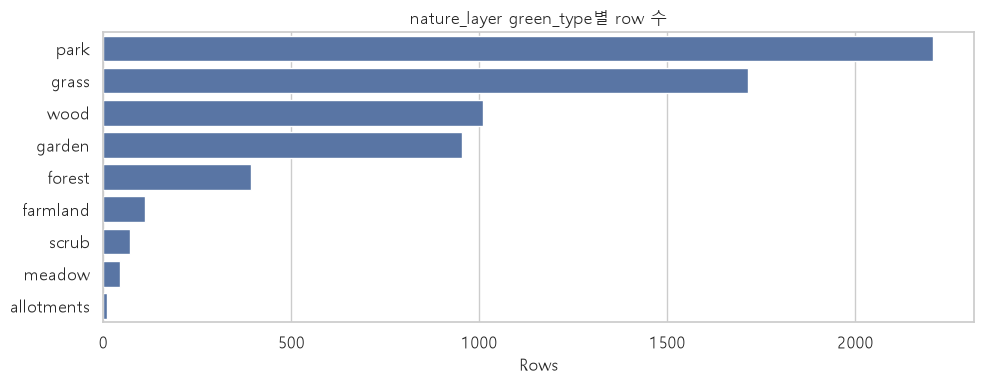

In [15]:
if nature_gdf.empty:
    green_type_counts = pd.DataFrame()
    print("nature_layer가 비어 있습니다.")
else:
    green_type_counts = (
        nature_gdf.groupby(["green_type", "green_weight"])
        .size()
        .reset_index(name="row_count")
        .sort_values("row_count", ascending=False)
    )
    display(green_type_counts)
    green_type_counts.to_csv(TABLE_DIR / "nature_layer_green_type_counts.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=green_type_counts, x="row_count", y="green_type")
    ax.set_title("nature_layer green_type별 row 수")
    ax.set_xlabel("Rows")
    ax.set_ylabel("")
    apply_korean_font(ax)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "nature_layer_green_type_count.png", dpi=160)
    plt.show()

## 11. osm_raw와 nature_layer 연결률 확인

`nature_layer.osm_raw_id`가 얼마나 채워져 있는지 확인한다.

연결률이 높으면 OSM raw가 실제 nature layer 구축에 대부분 반영되었다고 볼 수 있다.

In [16]:
if osm_gdf.empty or nature_gdf.empty:
    osm_nature_link_summary = pd.DataFrame()
    print("osm_gdf 또는 nature_gdf가 비어 있습니다.")
else:
    linked_osm_raw_ids = nature_gdf["osm_raw_id"].dropna().nunique()
    osm_nature_link_summary = pd.DataFrame([
        {
            "osm_raw_rows": len(osm_gdf),
            "nature_layer_rows": len(nature_gdf),
            "linked_osm_raw_ids": int(linked_osm_raw_ids),
            "osm_raw_linked_rate": linked_osm_raw_ids / len(osm_gdf),
        }
    ])
    display(osm_nature_link_summary)
    osm_nature_link_summary.to_csv(TABLE_DIR / "osm_nature_layer_link_summary.csv", index=False, encoding="utf-8-sig")

,osm_raw_rows,nature_layer_rows,linked_osm_raw_ids,osm_raw_linked_rate
0,6601,6515,6515,0.986972


## 12. boundary table 확인

자치구별 OSM 분포를 보려면 서울 25개 자치구 polygon이 필요하다.

현재 DB에 어떤 boundary table이 있는지 먼저 확인한다.

In [17]:
boundary_check_sql = text('''
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
  AND table_name ILIKE '%boundary%'
ORDER BY table_name
''')

try:
    with engine.connect() as conn:
        boundary_tables = pd.read_sql(boundary_check_sql, conn)
    display(boundary_tables)
except Exception as e:
    boundary_tables = pd.DataFrame()
    print("boundary table 확인 실패:", e)

,table_name
0,seoul_administrative_boundary


## 13. 서울 전체 boundary 기준 검증

현재 `seoul_administrative_boundary`가 서울 전체 polygon 1개만 있으면 자치구별 spatial join은 수행할 수 없다.

대신 서울 전체 boundary와 OSM 녹지 polygon이 교차/포함되는지 확인한다.

In [18]:
boundary_sql = '''
SELECT *
FROM seoul_administrative_boundary
'''

try:
    boundary_gdf = gpd.read_postgis(boundary_sql, engine, geom_col="geom", crs="EPSG:4326")
    print("boundary rows:", len(boundary_gdf))
    display(boundary_gdf.head())
except Exception as e:
    boundary_gdf = gpd.GeoDataFrame()
    print("boundary 로드 실패:", e)

if not boundary_gdf.empty and not nature_gdf.empty:
    osm_polygon = nature_gdf[nature_gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    seoul_boundary_5179 = boundary_gdf.to_crs(epsg=5179)
    seoul_area_km2 = seoul_boundary_5179.geometry.area.sum() / 1_000_000

    osm_polygon_5179 = osm_polygon.to_crs(epsg=5179)
    osm_polygon["area_km2"] = osm_polygon_5179.geometry.area / 1_000_000

    seoul_union = boundary_gdf.geometry.unary_union
    osm_polygon["intersects_seoul_boundary"] = osm_polygon.geometry.intersects(seoul_union)
    osm_polygon["within_seoul_boundary"] = osm_polygon.geometry.within(seoul_union)

    seoul_level_summary = pd.DataFrame([
        {
            "boundary_name": boundary_gdf.loc[0, "name"] if "name" in boundary_gdf.columns else "Seoul",
            "boundary_rows": len(boundary_gdf),
            "seoul_boundary_area_km2": seoul_area_km2,
            "osm_green_polygon_count": len(osm_polygon),
            "osm_green_area_km2": osm_polygon["area_km2"].sum(),
            "osm_green_area_ratio": osm_polygon["area_km2"].sum() / seoul_area_km2,
            "intersects_seoul_boundary_rows": int(osm_polygon["intersects_seoul_boundary"].sum()),
            "within_seoul_boundary_rows": int(osm_polygon["within_seoul_boundary"].sum()),
        }
    ])
    display(seoul_level_summary)
    seoul_level_summary.to_csv(TABLE_DIR / "osm_seoul_level_boundary_summary.csv", index=False, encoding="utf-8-sig")

boundary rows: 1


,id,name,geom
0,1,Seoul,"POLYGON ((126.76443 37.55532, 126.76452 37.555..."


,boundary_name,boundary_rows,seoul_boundary_area_km2,osm_green_polygon_count,osm_green_area_km2,osm_green_area_ratio,intersects_seoul_boundary_rows,within_seoul_boundary_rows
0,Seoul,1,605.928989,6515,315.60035,0.520854,6515,6411


## 14. row count 기준 순위와 area 기준 순위 비교

OSM polygon은 row 수와 면적이 다르게 움직인다.

따라서 `count_rank`와 `area_rank`를 비교해서 row 수만으로 해석하면 왜곡되는 query_key를 찾는다.

In [19]:
if "area_summary" not in globals() or area_summary.empty:
    osm_query_area_rank = pd.DataFrame()
    print("area_summary가 비어 있습니다.")
else:
    osm_query_area_rank = area_summary.copy()
    osm_query_area_rank["area_rank"] = osm_query_area_rank["sum"].rank(ascending=False)
    osm_query_area_rank["count_rank"] = osm_query_area_rank["count"].rank(ascending=False)
    display(osm_query_area_rank.sort_values("area_rank"))
    osm_query_area_rank.to_csv(TABLE_DIR / "osm_query_area_rank_compare.csv", index=False, encoding="utf-8-sig")

,query_key,count,sum,min,median,mean,max,area_rank,count_rank
8,natural=wood,1010,256.859030,3.214898e-06,0.001867,0.254316,45.207934,1.0,3.0
6,leisure=park,2205,38.843325,3.723323e-06,0.001658,0.017616,1.667397,2.0,1.0
1,landuse=farmland,111,7.401963,8.936435e-05,0.004632,0.066684,2.507906,3.0,6.0
2,landuse=forest,394,5.687388,2.564396e-06,0.000912,0.014435,1.253993,4.0,5.0
3,landuse=grass,1714,4.653796,2.494996e-06,0.000399,0.002715,0.259588,5.0,2.0
5,leisure=garden,955,1.883993,1.630893e-07,0.000205,0.001973,0.615664,6.0,4.0
7,natural=scrub,70,0.219601,9.033057e-06,0.000406,0.003137,0.060012,7.0,7.0
0,landuse=allotments,10,0.029250,2.497987e-05,0.000352,0.002925,0.014084,8.0,9.0
4,landuse=meadow,46,0.022005,1.428658e-05,0.000259,0.000478,0.002641,9.0,8.0


## 15. 자치구별 OSM 분포 분석 계획

정확한 자치구별 OSM 분포는 다음 조건이 필요하다.

- 자치구 polygon geometry
- 자치구명 컬럼
- OSM geometry와 같은 CRS
- polygon/line/point 유형에 맞는 spatial join 기준

자치구 boundary가 준비되면 다음 지표를 계산한다.

- 자치구별 OSM 녹지 count
- 자치구별 OSM 녹지 area_km2
- 자치구 면적 대비 OSM 녹지 density
- green_type별 자치구 편차

In [20]:
osm_gu_analysis_plan = pd.DataFrame([
    {
        "step": "자치구 boundary 확보",
        "needed_data": "서울 25개 자치구 polygon + gu 이름",
        "metric": "spatial join 준비",
        "status": "필요",
    },
    {
        "step": "OSM geometry 정제",
        "needed_data": "valid polygon/line geometry",
        "metric": "geometry null/invalid 제거",
        "status": "진행 가능",
    },
    {
        "step": "자치구별 spatial join",
        "needed_data": "OSM geometry + gu boundary",
        "metric": "gu별 count/area",
        "status": "boundary 필요",
    },
    {
        "step": "면적 대비 density 계산",
        "needed_data": "gu_area_km2",
        "metric": "osm_green_area_km2 / gu_area_km2",
        "status": "boundary 이후 가능",
    },
])

display(osm_gu_analysis_plan)
osm_gu_analysis_plan.to_csv(TABLE_DIR / "osm_gu_distribution_analysis_plan.csv", index=False, encoding="utf-8-sig")

,step,needed_data,metric,status
0,자치구 boundary 확보,서울 25개 자치구 polygon + gu 이름,spatial join 준비,필요
1,OSM geometry 정제,valid polygon/line geometry,geometry null/invalid 제거,진행 가능
2,자치구별 spatial join,OSM geometry + gu boundary,gu별 count/area,boundary 필요
3,면적 대비 density 계산,gu_area_km2,osm_green_area_km2 / gu_area_km2,boundary 이후 가능


## 16. 1차 해석 메모

OSM은 파일 기반 raw와 달리 공식 통계 원본이 아니라 커뮤니티 기반 지도 데이터다.

따라서 현재 단계에서 봐야 하는 것은 다음이다.

- 언제 수집되었는가
- 어떤 query_key/tag가 들어왔는가
- geometry가 유효한가
- 서울 범위 밖 geometry가 섞였는가
- 실제 nature_layer에 연결되어 있는가
- 자치구별 분포 분석을 위한 boundary가 준비되어 있는가

현재 상태에서 OSM은 최종 score 주 데이터라기보다 보조 공간 검증 데이터로 보는 것이 안전하다. 자치구별 편차 분석은 25개 자치구 boundary polygon이 확보된 뒤 spatial join으로 진행한다.